# Basic fit with SIXSA

In this tutorial, we demonstrate how one can fit a model on a spectrum using BSIXSA

In [1]:
import xspec

xspec.AllData.clear()
xspec.AllModels.clear()

xspec.Fit.statMethod = "cstat"
xspec.Fit.bayes = "on"

Default fit statistic is set to: C-Statistic
   This will apply to all current and newly loaded spectra.


In [2]:
from bsixsa import XSilence

with XSilence():
    xspec.Xset.abund = "wilm"
    xspec.Xset.xsect = "vern"
    model = xspec.Model("tbabs * (bbodyrad + powerlaw)")

model.show()

tbvabs Version 2.3
Cosmic absorption with grains and H2, modified from
Wilms, Allen, & McCray, 2000, ApJ 542, 914-924
Questions: Joern Wilms
joern.wilms@sternwarte.uni-erlangen.de
joern.wilms@fau.de

http://pulsar.sternwarte.uni-erlangen.de/wilms/research/tbabs/

PLEASE NOTICE:
To get the model described by the above paper
you will also have to set the abundances:
   abund wilm

Note that this routine ignores the current cross section setting
as it always HAS to use the Verner cross sections as a baseline.

Model TBabs<1>(bbodyrad<2> + powerlaw<3>) Source No.: 1   Active/Off
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   TBabs      nH         10^22    1.00000      +/-  0.0          
   2    2   bbodyrad   kT         keV      3.00000      +/-  0.0          
   3    2   bbodyrad   norm                1.00000      +/-  0.0          
   4    3   powerlaw   PhoIndex            1.00000      +/-  0.0          
   5    3   powerlaw   norm                1.00000      +/

In [3]:
with XSilence():

    observation = xspec.Spectrum(
        "PN_spectrum_grp20.fits",
        respFile="PN.rmf",
        arfFile="PN.arf",
    )

    observation.background = None

    low_energy, high_energy = 0.3, 10. # Set energy band
    observation.ignore(f"0.0-{low_energy:.1f} {high_energy:.1f}-**")

observation.show()

Spectrum 1  Spectral Data File: PN_spectrum_grp20.fits
Net count rate (cts/s) for Spectrum:1  5.508e-01 +/- 5.213e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  4-113
  Telescope: XMM Instrument: EPN  Channel Type: PI
  Exposure Time: 2.027e+04 sec
 Using fit statistic: cstat
 Using Response (RMF) File            PN.rmf for Source 1
 Using Auxiliary Response (ARF) File  PN.arf

 Spectral data counts: 11163
 Model predicted rate: 1481.25



In [4]:
from bsixsa.convenience import set_prior_and_build_transform

define_prior = [
    ("TBabs", "nH", 0.01, 0.2, "uniform"),
    ("bbodyrad", "kT", 0.05, 5.0, "uniform"),
    ("bbodyrad", "norm", 1e-3, 1e0, "loguniform"),
    ("powerlaw", "PhoIndex", 0.2, 7, "uniform"),
    ("powerlaw", "norm", 1e-6, 1e-1, "loguniform")
]

transformations = set_prior_and_build_transform(model, define_prior)

  uniform prior for nH between 0.010000 and 0.200000 
  uniform prior for kT between 0.050000 and 5.000000 
  jeffreys prior for norm between 1.000000e-03 and 1.000000e+00 
  uniform prior for PhoIndex between 0.200000 and 7.000000 
  jeffreys prior for norm between 1.000000e-06 and 1.000000e-01 


In [5]:
from bsixsa import SIXSASolver

solver = SIXSASolver(
    transformations,
    outputfiles_basename="results/",
    overwrite=True,
)

  0%|          | 0/100 [00:00<?, ?it/s]

The error "***XSPEC Error: Requested array does not exist for this plot." can be ignored.
***Warning: Fit is not current.
***Warning: Fit is not current.



***XSPEC Error: Requested array does not exist for this plot.


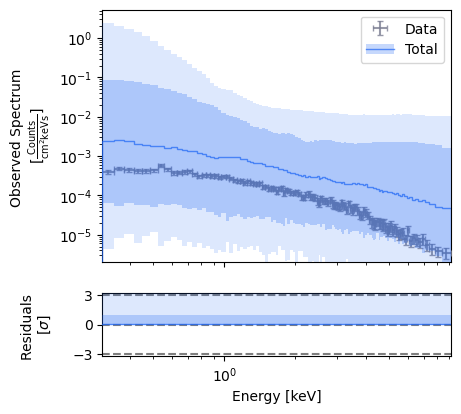

In [6]:
solver.plot_ppc("prior", component_names=["Total"], figsize=(4.5, 4.5));

In [7]:
import numpy as np
from bsixsa.embedding.trainable import AutoencoderEmbedding
from bsixsa.embedding.summary import GlobalSummaryEmbedding, LocalSumWithExtra
from bsixsa.embedding import MultipleEmbedding

summary_embedding = MultipleEmbedding([
    GlobalSummaryEmbedding(),
    LocalSumWithExtra(np.linspace(low_energy, high_energy, 31)),
])

aa_embedding = AutoencoderEmbedding(latent_dim=32, hidden=(2,), retrain_from_scratch=False)

In [8]:
posterior = solver.run(
    num_simulations_per_round=[20_000, 5_000, 5_000], # 3 rounds with 20_000, 5_000 and 5_000 simulations
    embedding=[summary_embedding, aa_embedding, aa_embedding] # First round will use summary statistics, second and third rounds use an autoencoder
)

Round 1 - Folding model:   0%|          | 0/20000 [00:00<?, ?it/s]

 Neural network successfully converged after 107 epochs.

Round 2 - Folding model:   0%|          | 0/5000 [00:00<?, ?it/s]

0it [00:00, ?it/s]

 Neural network successfully converged after 133 epochs.

...

0it [00:00, ?it/s]

 Neural network successfully converged after 55 epochs.

Folding model:   0%|          | 0/10000 [00:00<?, ?it/s]

Computing posterior statistic - Folding model:   0%|          | 0/1000 [00:00<?, ?it/s]

   All chains are now removed.
  New chain results/chain.fits is now loaded.
  Default chain length is now set to length of results/chain.fits: 1000


Folding model:   0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

The error "***XSPEC Error: Requested array does not exist for this plot." can be ignored.



***XSPEC Error: Requested array does not exist for this plot.


***Warning: Fit is not current.
***Warning: Fit is not current.


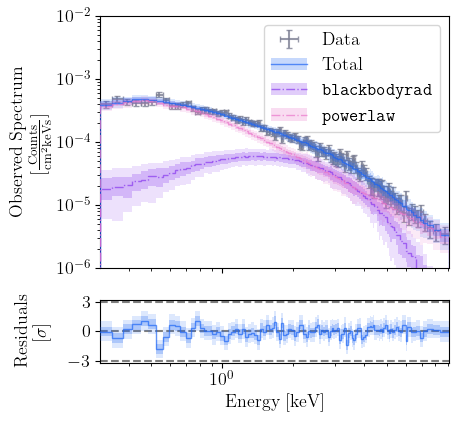

In [9]:
# Activate latex text rendering
import matplotlib
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Computer Modern Roman'], 'size':13})
rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble']=r"\usepackage{amsmath}"

# Plot the posterior predictive distribution using the exact sampler
component_names = ["Total", r"$\texttt{blackbodyrad}$", r"$\texttt{powerlaw}$"]
fig = solver.plot_ppc("exact_sampler", component_names=component_names, y_lim=(1e-6, 1e-2), figsize=(4.5,4.5), n_samples=1000);

In [10]:
sixsa_df = solver.build_dataframe(num_samples=50_000, weighted=False, oversampling_factor=10)

Folding model:   0%|          | 0/500000 [00:00<?, ?it/s]

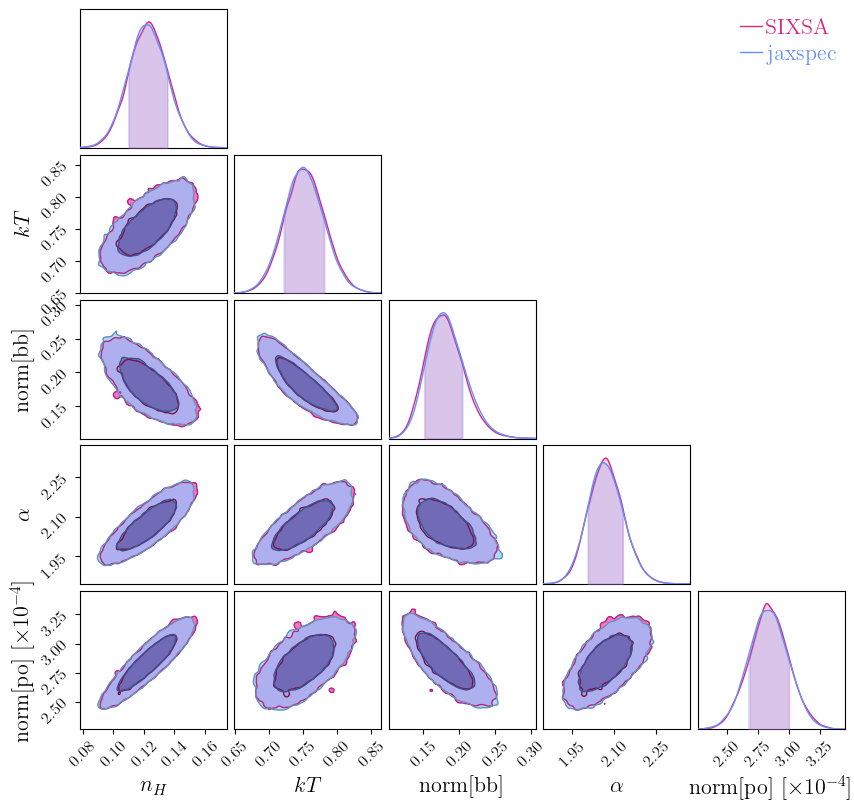

In [11]:
import pandas as pd
from chainconsumer import ChainConsumer, Chain, PlotConfig

jaxspec_df = pd.read_csv("jaxspec_dataframe.csv").drop(columns=["Unnamed: 0"])

cc = ChainConsumer()
cc.add_chain(Chain(samples=sixsa_df, name="SIXSA", color="#dc267f"))
#cc.add_chain(Chain(samples=sixsa_df_weighted, name="SIXSA Weighted", color="#54b04a"))
cc.add_chain(Chain(samples=jaxspec_df, name="jaxspec", color="#648fff"))
cc.set_plot_config(
    PlotConfig(
        usetex=True,
        label_font_size=16,
        tick_font_size=12,
        serif=True,
        labels={
            'norm (bb_1)':'norm[bb]',
            'norm (po_2)': 'norm[po]',
            'kT':r'$kT$',
            'PhoIndex':r'$\alpha$',
            'nH':r'$n_H$'
        }
    )
)

cc.plotter.plot(figsize=(9., 9.));